In [15]:
import demes 
import demesdraw 
import moments
import msprime 
import numpy as np
import dpluspy

In [16]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [17]:
# Define parameters
N_A = 10000
T_0 = 12000
N_1 = 5000
N_2 = 5000
T_1 = 2000
prop_1 = 0.5
N_X = 10000

model_str = f"""time_units: generations
demes:
- name: popA 
  epochs:
  - {{end_time: {T_0}, start_size: {N_A}}}    
- name: stem1 
  ancestors: [popA]
  epochs:
  - {{end_time: {T_1}, start_size: {N_1}}}      
- name: stem2 
  ancestors: [popA]
  epochs:
  - {{end_time: {T_1}, start_size: {N_2}}}    
- name: popX 
  start_time: {T_1}
  ancestors: [stem1, stem2]
  proportions: [{prop_1}, {1 - prop_1}]
  epochs:
  - {{end_time: 0, start_size: {N_X}}}     
"""

with open("structure_model.yaml", "w") as fout:
    fout.write(model_str)

times = np.linspace(0, T_0 * 1.05, 100)
times = np.sort(np.concatenate([times, [T_0, T_1]]))

structure_model = demes.load("structure_model.yaml")
structure_demog = msprime.Demography.from_demes(structure_model)
structure_debug = structure_demog.debug()
structure_lam, _ = structure_debug.coalescence_rate_trajectory(times, {"popX": 2})

In [18]:
# Exponential model
N_start = 1 / (2 * structure_lam[np.where(times == T_0)[0][0]])
N_end = 1 / (2 * structure_lam[np.where(times == T_1)[0][0]])
model_str = f"""time_units: generations
demes:
- name: popX 
  epochs:
  - {{end_time: {T_0}, start_size: {N_A}}}
  - {{end_time: {T_1}, start_size: {N_start}, end_size: {N_end}}}   
  - {{end_time: 0, start_size: {N_X}}}
"""

with open("exponential_model.yaml", "w") as fout:
    fout.write(model_str)

exponential_model = demes.load("exponential_model.yaml")
exponential_demog = msprime.Demography.from_demes(exponential_model)
exponential_debug = exponential_demog.debug()
exponential_lam, _ = exponential_debug.coalescence_rate_trajectory(times, {"popX": 2})

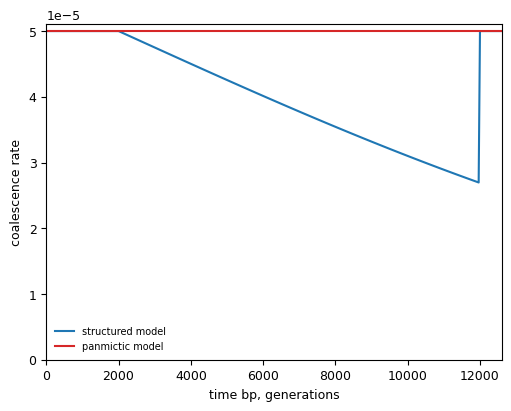

In [19]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

ax.plot(times, structure_lam, color="tab:blue", label="structured model")
ax.plot(times, exponential_lam, color="tab:red", label="panmictic model")

ax.set_ylim(0, )
ax.set_xlim(0, times[-1])
ax.set_ylabel("coalescence rate")
ax.set_xlabel("time bp, generations")
ax.legend(framealpha=0)

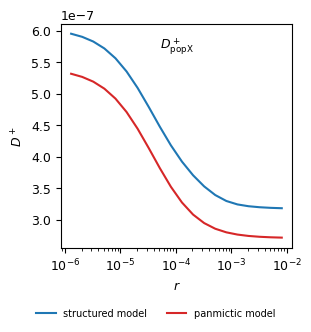

In [20]:
# expectations
u = 1.3e-8
bins = np.logspace(-6, -2, 21)
structure_exp = dpluspy.inference.compute_bin_stats(structure_model, 
    u=u, bins=bins, sampled_demes=["popX"])
exponential_exp = dpluspy.inference.compute_bin_stats(exponential_model, 
    u=u, bins=bins, sampled_demes=["popX"])

dpluspy.plotting.plot_d_plus_curves(models=[structure_exp, exponential_exp],
    bins=bins, labels=["structured model", "panmictic model"], pop_ids=["popX"],
    colors=["tab:blue", "tab:red"], ax_size=3)